In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime
import warnings

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

# Load the dataset (update the filename if yours differs)
df = pd.read_csv('/content/car data.csv')

print("Initial Shape:", df.shape)
display(df.head())

Initial Shape: (301, 9)


,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [2]:
# 1. Handle Nulls and Duplicates
df.dropna(inplace=True)
df.drop_duplicates(inplace=True)

# 2. Standardize Categorical Values (e.g., lowercasing)
categorical_cols = ['Fuel_Type', 'Seller_Type', 'Transmission']
for col in categorical_cols:
    if col in df.columns:
        df[col] = df[col].astype(str).str.lower()

# 3. Feature Engineering: Car Age
current_year = datetime.datetime.now().year
df['Age'] = current_year - df['Year']

# 4. Feature Engineering: Extract Brand from Car Name
if 'Car_Name' in df.columns:
    df['Brand'] = df['Car_Name'].apply(lambda x: str(x).split(' ')[0].capitalize())
    # Drop original Car_Name and Year as we've extracted their value
    df.drop(['Car_Name', 'Year'], axis=1, inplace=True)

print("\nShape after cleaning and engineering:", df.shape)
display(df.head())


Shape after cleaning and engineering: (299, 9)


,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Age,Brand
0,3.35,5.59,27000,petrol,dealer,manual,0,12,Ritz
1,4.75,9.54,43000,diesel,dealer,manual,0,13,Sx4
2,7.25,9.85,6900,petrol,dealer,manual,0,9,Ciaz
3,2.85,4.15,5200,petrol,dealer,manual,0,15,Wagon
4,4.60,6.87,42450,diesel,dealer,manual,0,12,Swift


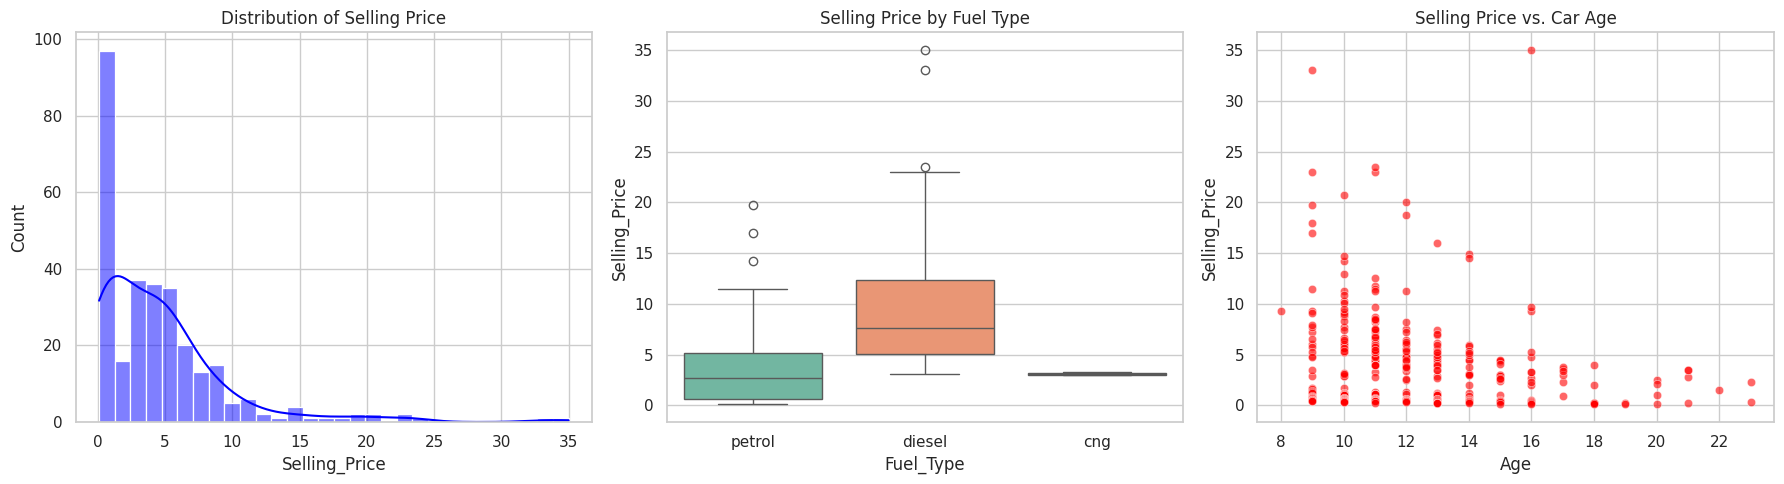

In [3]:
plt.figure(figsize=(18, 5))

# 1. Distribution of Selling Prices
plt.subplot(1, 3, 1)
sns.histplot(df['Selling_Price'], kde=True, color='blue', bins=30)
plt.title('Distribution of Selling Price')

# 2. Price vs. Fuel Type Box Plot
plt.subplot(1, 3, 2)
if 'Fuel_Type' in df.columns:
    sns.boxplot(x='Fuel_Type', y='Selling_Price', data=df, palette='Set2')
    plt.title('Selling Price by Fuel Type')

# 3. Price vs. Car Age Scatter Plot
plt.subplot(1, 3, 3)
sns.scatterplot(x='Age', y='Selling_Price', data=df, alpha=0.6, color='red')
plt.title('Selling Price vs. Car Age')

plt.tight_layout()
plt.show()

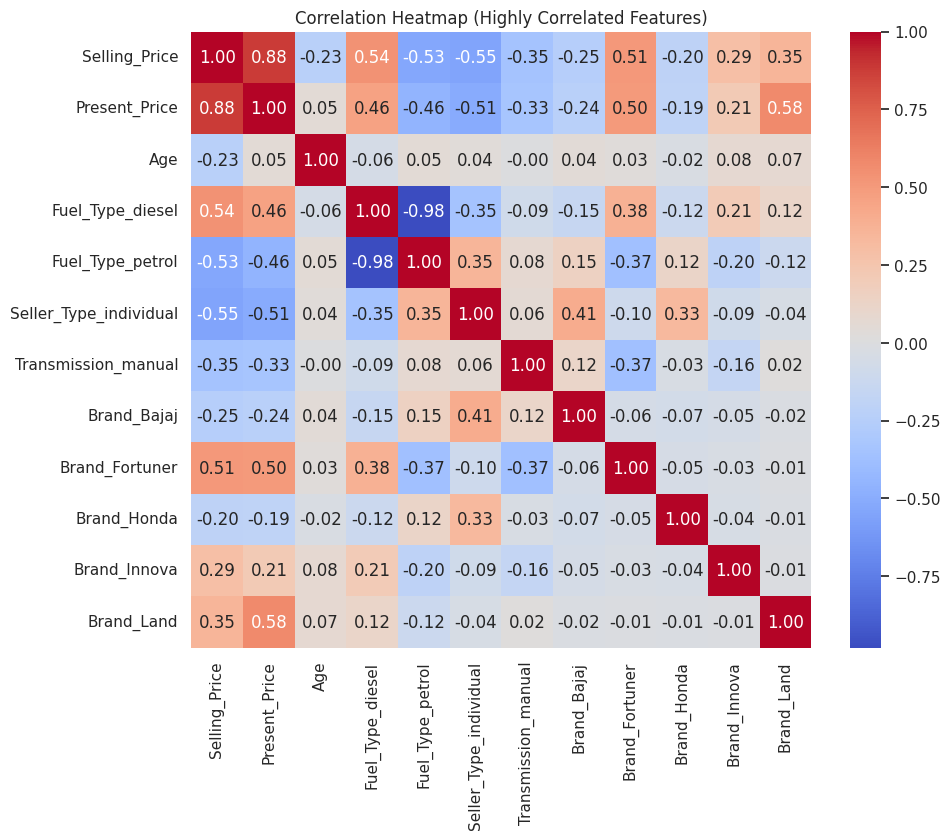

In [4]:
# One-Hot Encode categorical variables (Brand, Fuel_Type, Seller_Type, Transmission)
df_encoded = pd.get_dummies(df, drop_first=True)

# Correlation Heatmap
plt.figure(figsize=(10, 8))
# Select only top 15 correlated features with Selling_Price to keep heatmap readable
corr_matrix = df_encoded.corr()
top_corr_features = corr_matrix.index[abs(corr_matrix["Selling_Price"]) > 0.2]
sns.heatmap(df_encoded[top_corr_features].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap (Highly Correlated Features)")
plt.show()

In [5]:
# Prepare features and target
X = df_encoded.drop('Selling_Price', axis=1)
y = df_encoded['Selling_Price']

# 80/20 Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Optional but recommended: Scale the numerical features for Linear Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Model 1: Linear Regression
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

# Model 2: Random Forest Regressor
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train) # RF doesn't strictly need scaling
y_pred_rf = rf.predict(X_test)

--- Linear Regression ---
MAE:  1.81
RMSE: 3.40
R²:   0.5517

--- Random Forest Regressor ---
MAE:  1.32
RMSE: 3.18
R²:   0.6082



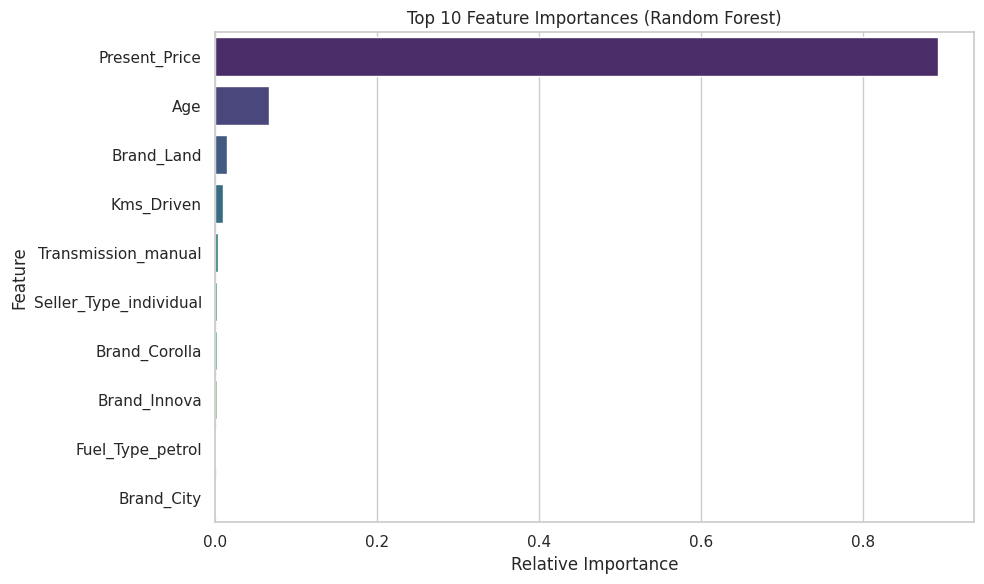

In [6]:
def evaluate(model_name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"--- {model_name} ---")
    print(f"MAE:  {mae:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"R²:   {r2:.4f}\n")

evaluate("Linear Regression", y_test, y_pred_lr)
evaluate("Random Forest Regressor", y_test, y_pred_rf)

# Feature Importance Chart for Random Forest (Best Model)
importance = rf.feature_importances_
feature_names = X.columns
feature_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importance}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_imp_df.head(10), palette='viridis')
plt.title('Top 10 Feature Importances (Random Forest)')
plt.xlabel('Relative Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()